# Phân tích khám phá dữ liệu (EDA) thị trường cho thuê RoomBeacon

Notebook này bao gồm các phần sau:

- [Nhập các thư viện](#nhập-các-thư-viện)

- [Kết nối DuckDB và tải tập dữ liệu](#kết-nối-duckdb-và-tải-tập-dữ-liệu)

- [Tổng quan về dataset](#tổng-quan-về-dataset)

- [Đánh giá chất lượng dữ liệu](#đánh-giá-chất-lượng-dữ-liệu)

- [Phân tích nguồn dữ liệu](#phân-tích-nguồn-dữ-liệu)

- [Phân tích giá thuê](#phân-tích-giá-thuê)

- [Phân tích diện tích cho thuê](#phân-tích-diện-tích-cho-thuê)

- [Phát hiện giá trị ngoại lệ](#phát-hiện-giá-trị-ngoại-lệ)

- [Phân tích mối quan hệ](#phân-tích-mối-quan-hệ)

- [Phân tích theo thời gian](#phân-tích-theo-thời-gian)

- [Tóm tắt nhận định dữ liệu](#tóm-tắt-nhận-định-dữ-liệu)

## Nhập các thư viện
Phần này nhập các thư viện Python cần thiết để xử lý dữ liệu, trực quan hóa và thực hiện phân tích khám phá dữ liệu.

In [91]:
try:
    from utils import setup_project_path
except ModuleNotFoundError:
    from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env", override=False)
from utils.location_normalizer import apply_location_mapping
import numpy as np
import pandas as pd
from analytics.duckdb.connection import create_analytics_connection
from utils.address_cleaner import clean_address
from utils.location_normalizer import apply_location_mapping, normalize_location, normalize_text
import seaborn as sns
import matplotlib.pyplot as plt
print("Đã nhập thư viện và thiết lập môi trường thành công.")

Đã phát hiện thư mục gốc của dự án RoomBeacon: /mnt/Data/projects/roombeacon
Đã nhập thư viện và thiết lập môi trường thành công.


## Kết nối DuckDB và tải tập dữ liệu

Phần này kết nối với cơ sở dữ liệu DuckDB của RoomBeacon và tải tập dữ liệu phân tích vào Pandas DataFrame để thực hiện phân tích khám phá.

In [92]:
# Factory của dự án tạo catalog DuckDB, gắn Bronze MySQL bằng cú pháp DSN
# key=value tương thích với DuckDB và khởi tạo các analytical view.
conn = create_analytics_connection()

attached_databases = {row[0] for row in conn.execute("SHOW DATABASES").fetchall()}
if "mysql_db" not in attached_databases:
    raise RuntimeError(
        "DuckDB không thể gắn Bronze MySQL. Hãy bảo đảm mysql-bronze đang chạy "
        "và thông tin kết nối BRONZE_MYSQL_HOST/PORT trong .env có thể truy cập "
        "từ môi trường notebook hiện tại."
    )

In [93]:
print("Đã kết nối thành công!")
conn.sql("SHOW TABLES;").show()

Đã kết nối thành công!
┌──────────────────────────┐
│           name           │
│         varchar          │
├──────────────────────────┤
│ v_acquisition_efficiency │
│ v_content_changes        │
│ v_data_quality           │
│ v_latest_posts           │
│ v_listing_lifetime       │
│ v_location_summary       │
│ v_observations           │
│ v_price_history          │
│ v_source_activity        │
└──────────────────────────┘



In [47]:
df = conn.sql("SELECT * FROM v_latest_posts").df()
type(df)

pandas.DataFrame

## Tổng quan về dataset

Phần này cung cấp cái nhìn tổng quan về tập dữ liệu được sử dụng trong quá trình EDA.

Các mục tiêu chính bao gồm:

- Kiểm tra kích thước tổng thể của tập dữ liệu.
- Xác nhận cấu trúc và lược đồ của dữ liệu.
- Kiểm tra thông tin các trường dữ liệu.
- Quan sát một số bản ghi mẫu.
- Đánh giá sơ bộ các biến số quan trọng trước khi thực hiện phân tích chuyên sâu.

Các nội dung thực hiện:

- Kích thước tập dữ liệu:
    - Số lượng bản ghi.
    - Số lượng đặc trưng.

- Xem trước tập dữ liệu:
    - Quan sát dữ liệu mẫu.
    - Kiểm tra định dạng và giá trị ban đầu.

- Thông tin tập dữ liệu:
    - Tên các cột.
    - Kiểu dữ liệu.
    - Số lượng giá trị không bị thiếu.

- Thống kê cơ bản:
    - Thống kê mô tả các biến số.
    - Kiểm tra phạm vi giá trị của các trường dạng số.

Kết quả của phần này giúp xác định cấu trúc tập dữ liệu và chuẩn bị cho các bước tiếp theo như đánh giá chất lượng dữ liệu và phân tích khám phá.

### Kích thước tập dữ liệu
Kiểm tra kích thước tổng thể của tập dữ liệu bao gồm:

- Số lượng bản ghi (hàng).
- Số lượng đặc trưng (cột).

In [48]:
df.shape

(97060, 14)

In [49]:
df.columns

Index(['source_code', 'rental_post_id', 'source_listing_id', 'title_raw',
       'url', 'price_amount', 'area_value', 'full_address_text',
       'location_raw', 'full_address_inherited', 'latest_observed_at',
       'first_observed_at', 'last_observed_at', 'active_days'],
      dtype='str')

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97060 entries, 0 to 97059
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   source_code             97060 non-null  str           
 1   rental_post_id          97060 non-null  int64         
 2   source_listing_id       97060 non-null  str           
 3   title_raw               96384 non-null  str           
 4   url                     97060 non-null  str           
 5   price_amount            89887 non-null  float64       
 6   area_value              85785 non-null  float64       
 7   full_address_text       25391 non-null  str           
 8   location_raw            25391 non-null  str           
 9   full_address_inherited  97060 non-null  bool          
 10  latest_observed_at      97060 non-null  datetime64[us]
 11  first_observed_at       97060 non-null  datetime64[us]
 12  last_observed_at        97060 non-null  datetime64[us]
 1

### Thông tin các trường dữ liệu

Tập dữ liệu `v_latest_posts` gồm 14 trường dữ liệu chính, đại diện cho thông tin định danh, thuộc tính, vị trí và vòng đời của tin đăng cho thuê.

Các nhóm trường chính:

### Thông tin định danh và nguồn dữ liệu

- `source_code`: Nguồn dữ liệu được thu thập, xác định nền tảng đăng tin.
- `rental_post_id`: Mã định danh nội bộ duy nhất của RoomBeacon cho mỗi tin đăng.
- `source_listing_id`: Mã định danh gốc của tin đăng trên trang web nguồn.
- `url`: Đường dẫn truy cập tin đăng gốc.

### Thuộc tính tin đăng

- `title_raw`: Tiêu đề nguyên bản của tin đăng.
- `price_amount`: Giá thuê được bóc tách dạng số (VNĐ/tháng).
- `area_value`: Diện tích tin đăng (m²).

### Thông tin vị trí

- `full_address_text`: Địa chỉ chi tiết thu thập từ nguồn.
- `location_raw`: Trường địa chỉ thô phục vụ phân tích vị trí.
- `full_address_inherited`: Đánh dấu địa chỉ được lấy trực tiếp hay kế thừa từ lịch sử quan sát.

### Thời gian và vòng đời

- `latest_observed_at`: Thời điểm hệ thống thu thập quan sát tin gần nhất.
- `first_observed_at`: Thời điểm đầu tiên phát hiện tin đăng.
- `last_observed_at`: Thời điểm cuối cùng ghi nhận hoạt động.
- `active_days`: Số ngày tin đăng tồn tại trên hệ thống.

Các trường dữ liệu này phục vụ cho các bước phân tích tiếp theo như:
- Đánh giá chất lượng dữ liệu.
- Phân tích giá thuê và diện tích.
- Phân tích nguồn dữ liệu.
- Nghiên cứu vòng đời tin đăng.

### Xem trước tập dữ liệu
- Quan sát dữ liệu mẫu.
- Kiểm tra định dạng và giá trị ban đầu.


In [51]:
df.head(5)

,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,area_value,full_address_text,location_raw,full_address_inherited,latest_observed_at,first_observed_at,last_observed_at,active_days
0,cafeland,791099,2856186,Cho thuê phòng trọ: Phòng Cao Cấp Gác Cao Cửa ...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,3500000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:37,2026-08-28 04:00:19,2026-09-01 04:16:37,4
1,cafeland,791098,2856191,Cho thuê phòng trọ: Cho thuê Nhà trọ đầy đủ ti...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,6200000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:34,2026-08-28 04:00:18,2026-09-01 04:16:34,4
2,cafeland,791097,2856193,Cho thuê phòng trọ: Cho thuê phòng KTX sinh vi...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,1500000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:31,2026-08-28 04:00:18,2026-09-01 04:16:31,4
3,cafeland,791096,2856196,Cho thuê phòng trọ: Cho Thuê Phòng Cửa Sổ Thoá...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,4000000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:28,2026-08-28 04:00:18,2026-09-01 04:16:28,4
4,cafeland,791095,2856197,"Cho thuê phòng trọ: Phòng gác 25m2 ban công 5,...",https://nhadat.cafeland.vn/cho-thue-phong-tro-...,5900000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:25,2026-08-28 04:00:18,2026-09-01 04:16:25,4


In [52]:
# Kiểm tra số bản ghi có full_address_inherited = true
address_inherited = conn.query("SELECT COUNT(*) FROM v_latest_posts WHERE full_address_inherited = 1")
print(address_inherited)

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│         1800 │
└──────────────┘



In [53]:
# Tổng quan về các đặc trưng dạng số
# Khảo sát phân phối thống kê của các trường dạng số quan trọng:
# price_amount, area_value và active_days.

overview_features = [
    "rental_post_id",
    "price_amount",
    "area_value",
    "active_days",
    "full_address_text",
    "location_raw"
]

df[overview_features].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rental_post_id,97060.0,NaN,NaN,NaN,840579.07279,52986.234407,757140.0,794508.75,836429.5,879867.25,952504.0
price_amount,89887.0,NaN,NaN,NaN,4774344.333764,34379041.535677,3500.0,3000000.0,4000000.0,5800000.0,7777000000.0
area_value,85785.0,NaN,NaN,NaN,31.24519,43.44458,1.0,25.0,30.0,35.0,10000.0
active_days,97060.0,NaN,NaN,NaN,0.590779,1.213219,0.0,0.0,0.0,0.0,8.0
full_address_text,25391,8393,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",4774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_raw,25391,8393,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",4774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Tổng quan các đặc trưng của tập dữ liệu

Thống kê mô tả cung cấp góc nhìn ban đầu về số lượng giá trị, phân phối và phạm vi của các trường quan trọng. Những quan sát này là cơ sở để xác định nội dung cần kiểm tra sâu hơn, chưa phải kết luận cuối cùng về chất lượng dữ liệu.

## Đánh giá chất lượng dữ liệu

Phần này đánh giá chất lượng dữ liệu trước khi thực hiện làm sạch, tập trung vào dữ liệu thiếu, dữ liệu trùng lặp và các vấn đề về tính hợp lệ. Các phát hiện sẽ được sử dụng để xây dựng quy tắc làm sạch phù hợp cho tập dữ liệu RoomBeacon.

### Phân tích dữ liệu thiếu

**Mục tiêu:**

- Kiểm tra mức độ thiếu dữ liệu của các trường quan trọng.
- Xác định các trường dữ liệu cần được điều tra thêm trước khi xây dựng quy tắc làm sạch.

Dữ liệu thiếu chưa đồng nghĩa với lỗi dữ liệu. Với `price_amount`, giá trị `NULL` có thể xuất hiện khi trang web không cung cấp giá số, tin đăng hiển thị "Thỏa thuận", bộ phân tích cú pháp chưa trích xuất được dữ liệu hoặc các nguồn sử dụng định dạng khác nhau. Cần kiểm tra bằng chứng từ dữ liệu gốc trước khi kết luận nguyên nhân.

### Điều tra dữ liệu thiếu giá

Biểu thức `missing_price = df[df["price_amount"].isna()]` lọc các tin đăng chưa có giá số để phục vụ điều tra. Việc lấy thêm `source_code`, `url` và `title_raw` giúp:

- Truy ngược nguồn dữ liệu.
- Đối chiếu nội dung thực tế trên trang web.
- Xác định nguyên nhân thiếu dữ liệu dựa trên bằng chứng thay vì suy đoán.

In [54]:
# Kiểm tra các giá trị NaN
missing_price = df[df["price_amount"].isna()]
missing_price[
    [
        "source_code",
        "url",
        "title_raw"
    ]
].head()

,source_code,url,title_raw
62,tromoi,https://tromoi.com/can-ho/can-ho-cao-cap-canh-...,Căn hộ cao cấp cạnh ngay vivo city quận 7
108,tromoi,https://tromoi.com/ky-tuc-xa/ki-tuc-xa-thien-dang,"KÝ TÚC XÁ SINH VIÊN GẦN HUIT, HUFI, NTTU, HITC..."
218,cafeland,https://nhadat.cafeland.vn/cho-thue-phong-binh...,Cho thuê phòng Bình Thạnh giáp trung tâm Q1
223,cafeland,https://nhadat.cafeland.vn/phong-tro-cho-thue-...,Phòng trọ: Cho thuê Phòng ngay Lũy Bán Bích
224,cafeland,https://nhadat.cafeland.vn/moi-gioi/cat-binh-2...,Cát Bình


In [55]:
df["source_code"].value_counts()

source_code
mogi               45444
chothuephongtro    35645
cafeland           10010
nhatot              2811
phongtro123         1167
tromoi              1019
nhatrovn             888
chothuenha            76
Name: count, dtype: int64

# Đánh giá chất lượng dữ liệu

Phần này đánh giá chất lượng dữ liệu hiện tại trước khi thực hiện các bước làm sạch và chuẩn hóa.

Mục tiêu của bước này là xác định các vấn đề có thể ảnh hưởng đến quá trình phân tích và xây dựng các quy tắc xử lý dữ liệu phù hợp.

Các kiểm tra chính bao gồm:

- **Dữ liệu thiếu**: Đánh giá mức độ thiếu dữ liệu của các trường quan trọng như giá thuê, diện tích và thông tin vị trí.
- **Kiểm tra tính hợp lệ của dữ liệu**: Kiểm tra kiểu dữ liệu, khoảng giá trị và các ràng buộc nghiệp vụ.
- **Kiểm tra trùng lặp**: Phát hiện các bản ghi trùng lặp trong tập dữ liệu.
- **Kiểm tra thông tin vị trí**: Kiểm tra và chuẩn hóa thông tin địa chỉ theo cấu trúc hành chính.

Các vấn đề phát hiện trong bước này sẽ được sử dụng để xây dựng quy trình làm sạch và chuyển đổi trước khi tạo tập dữ liệu phục vụ cho các bước phân tích tiếp theo.

In [56]:
df.dtypes

source_code                          str
rental_post_id                     int64
source_listing_id                    str
title_raw                            str
url                                  str
price_amount                     float64
area_value                       float64
full_address_text                    str
location_raw                         str
full_address_inherited              bool
latest_observed_at        datetime64[us]
first_observed_at         datetime64[us]
last_observed_at          datetime64[us]
active_days                        int64
dtype: object

In [57]:
df.isnull().sum()

source_code                   0
rental_post_id                0
source_listing_id             0
title_raw                   676
url                           0
price_amount               7173
area_value                11275
full_address_text         71669
location_raw              71669
full_address_inherited        0
latest_observed_at            0
first_observed_at             0
last_observed_at              0
active_days                   0
dtype: int64

In [58]:
missing_rate = (
    df.isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_rate

location_raw              73.84
full_address_text         73.84
area_value                11.62
price_amount               7.39
title_raw                  0.70
rental_post_id             0.00
url                        0.00
source_listing_id          0.00
source_code                0.00
full_address_inherited     0.00
latest_observed_at         0.00
first_observed_at          0.00
last_observed_at           0.00
active_days                0.00
dtype: float64

In [59]:
df[df["full_address_text"].isna()]["source_code"].value_counts()

source_code
mogi               39099
chothuephongtro    29218
cafeland            3288
nhatot                58
phongtro123            5
tromoi                 1
Name: count, dtype: int64

#### thay đổi tên các cột 

In [60]:
df_work = df.copy()

In [61]:
df_work.head(10)

,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,area_value,full_address_text,location_raw,full_address_inherited,latest_observed_at,first_observed_at,last_observed_at,active_days
0,cafeland,791099,2856186,Cho thuê phòng trọ: Phòng Cao Cấp Gác Cao Cửa ...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,3500000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:37,2026-08-28 04:00:19,2026-09-01 04:16:37,4
1,cafeland,791098,2856191,Cho thuê phòng trọ: Cho thuê Nhà trọ đầy đủ ti...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,6200000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:34,2026-08-28 04:00:18,2026-09-01 04:16:34,4
2,cafeland,791097,2856193,Cho thuê phòng trọ: Cho thuê phòng KTX sinh vi...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,1500000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:31,2026-08-28 04:00:18,2026-09-01 04:16:31,4
3,cafeland,791096,2856196,Cho thuê phòng trọ: Cho Thuê Phòng Cửa Sổ Thoá...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,4000000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:28,2026-08-28 04:00:18,2026-09-01 04:16:28,4
4,cafeland,791095,2856197,"Cho thuê phòng trọ: Phòng gác 25m2 ban công 5,...",https://nhadat.cafeland.vn/cho-thue-phong-tro-...,5900000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:25,2026-08-28 04:00:18,2026-09-01 04:16:25,4
5,cafeland,791093,2856199,Cho thuê phòng trọ: Cho thuê phòng trọ tại Lê ...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,4200000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:22,2026-08-28 04:00:18,2026-09-01 04:16:22,4
6,cafeland,791092,2856202,Cho thuê phòng trọ: Duplex đầy đủ nội thất nga...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,3800000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:19,2026-08-28 04:00:18,2026-09-01 04:16:19,4
7,chothuephongtro,798493,ho-chi-minh/quan-7/155811,"Căn hộ Q7 thiết kế sang trọng, thoáng mát có c...",https://chothuephongtro.me/ho-chi-minh/quan-7/...,6500000.0,40.0,Hưng gia 5 Tân Phong Q7,Hưng gia 5 Tân Phong Q7,False,2026-09-01 04:16:18,2026-08-28 05:20:15,2026-09-01 04:16:18,4
8,cafeland,791091,2856205,Cho thuê phòng trọ: Cho thuê studio full nội t...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,5000000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:16,2026-08-28 04:00:18,2026-09-01 04:16:16,4
9,chothuephongtro,798492,ho-chi-minh/quan-7/155814,CHDV DUPLEX CỬA SỔ LỚN FULL NỘI THẤT TRUNG TÂM...,https://chothuephongtro.me/ho-chi-minh/quan-7/...,6500000.0,36.0,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...","Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",False,2026-09-01 04:16:15,2026-08-28 05:20:15,2026-09-01 04:16:15,4


In [62]:
# rename columns 
df_work = df_work.rename(
    columns={
        "source_code": "domain",
        "rental_post_id": "roombeacon_id",
        "source_listing_id": "website_id",
        "title_raw": "title",
        "url": "post_url",
        "price_amount": "monthly_price",
        "area_value": "area_m2",
        "full_address_text": "address",
        "location_raw": "location",
        "full_address_inherited": "address_inherited",
        "latest_observed_at": "latest_seen_at",
        "first_observed_at": "first_seen_at",
        "last_observed_at": "last_seen_at",
        "active_days": "active_days"
    }
)

In [63]:
df_work.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days'],
      dtype='str')

In [64]:
df_work.head(5)

,domain,roombeacon_id,website_id,title,post_url,monthly_price,area_m2,address,location,address_inherited,latest_seen_at,first_seen_at,last_seen_at,active_days
0,cafeland,791099,2856186,Cho thuê phòng trọ: Phòng Cao Cấp Gác Cao Cửa ...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,3500000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:37,2026-08-28 04:00:19,2026-09-01 04:16:37,4
1,cafeland,791098,2856191,Cho thuê phòng trọ: Cho thuê Nhà trọ đầy đủ ti...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,6200000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:34,2026-08-28 04:00:18,2026-09-01 04:16:34,4
2,cafeland,791097,2856193,Cho thuê phòng trọ: Cho thuê phòng KTX sinh vi...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,1500000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:31,2026-08-28 04:00:18,2026-09-01 04:16:31,4
3,cafeland,791096,2856196,Cho thuê phòng trọ: Cho Thuê Phòng Cửa Sổ Thoá...,https://nhadat.cafeland.vn/cho-thue-phong-tro-...,4000000.0,NaN,Thông Tây Hội TP. Hồ Chí Minh,Thông Tây Hội TP. Hồ Chí Minh,False,2026-09-01 04:16:28,2026-08-28 04:00:18,2026-09-01 04:16:28,4
4,cafeland,791095,2856197,"Cho thuê phòng trọ: Phòng gác 25m2 ban công 5,...",https://nhadat.cafeland.vn/cho-thue-phong-tro-...,5900000.0,NaN,Bình Lợi Trung TP. Hồ Chí Minh,Bình Lợi Trung TP. Hồ Chí Minh,False,2026-09-01 04:16:25,2026-08-28 04:00:18,2026-09-01 04:16:25,4


# histogram

In [65]:
df_work["address_clean"] = (
    df_work["address"]
    .apply(clean_address)
)

In [66]:
df_work[
    df_work["address_clean"].notna()
][
    [
        "address",
        "address_clean"
    ]
].sample(20)

,address,address_clean
12312,"Huỳnh Tấn Phát, Quận7 Thuận tiện di chuyển các...","Huỳnh Tấn Phát, Quận 7 Thuận tiện di chuyển cá..."
57563,Bảy Hiền TP. Hồ Chí Minh,Bảy Hiền TP. Hồ Chí Minh
34213,"Kinh Dương Vương, Phường 12, Quận 6, TPHCM","Kinh Dương Vương, Phường 12, Quận 6, TPHCM"
19596,"Nguyễn Thị Thập, Phường Tân Quy, Quận 7, TPHCM","Nguyễn Thị Thập, Phường Tân Quy, Quận 7, TPHCM"
28290,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...","Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2..."
68093,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...","Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2..."
11070,Bình Hưng Hòa TP. Hồ Chí Minh,Bình Hưng Hòa TP. Hồ Chí Minh
24001,"Võ Oanh, Phường 25, Quận Bình Thạnh, TPHCM","Võ Oanh, Phường 25, Quận Bình Thạnh, TPHCM"
55915,"456/39G , Đường Cao Thắng, Phường 12, Quận 10,...","456, 39G, Đường Cao Thắng, Phường 12, Quận 10,..."
71426,"Quận Bình Thạnh , Thành phố Hồ Chí Minh","Quận Bình Thạnh, TPHCM"


In [67]:
df_work = apply_location_mapping(df_work)

In [68]:
df_work["address"].isna().mean()

np.float64(0.7383989284978364)

In [69]:
df_work["current_location"] = (
    df_work["address_clean"]
    .apply(normalize_location)
)

In [70]:
df_work[
    [
        "address_clean",
        "current_location"
    ]
].dropna(
    subset=["current_location"]
).sample(20)

,address_clean,current_location
14088,NaN,[]
53670,NaN,[]
95895,"7x, 11 Trần Thái Tông, Phường 15, Quận Tân Bìn...","[Phường Tân Bình, Phường Tân Sơn]"
7329,NaN,[]
9066,NaN,[]
22595,An Đông TP. Hồ Chí Minh,[]
16515,NaN,[]
48723,NaN,[]
12533,Thông Tây Hội TP. Hồ Chí Minh,[]
22289,"Nguyễn Tuyển, Phường Bình Trưng Tây, Quận 2, T...",[Phường Bình Trưng]


In [71]:
print(normalize_location("Lê Văn Quới, Phường Bình Trị Đông, Quận Bình Tân"))

['Phường Bình Trị Đông']


In [72]:
print(normalize_location("Phường 10, Quận 6, TPHCM"))

['Phường Bình Phú']


In [73]:
df_work = apply_location_mapping(df_work)

In [74]:
df_work[["address_clean", "current_location"]].head(20)

,address_clean,current_location
0,Thông Tây Hội TP. Hồ Chí Minh,[]
1,Thông Tây Hội TP. Hồ Chí Minh,[]
2,Bình Lợi Trung TP. Hồ Chí Minh,[]
3,Thông Tây Hội TP. Hồ Chí Minh,[]
4,Bình Lợi Trung TP. Hồ Chí Minh,[]
5,Bình Lợi Trung TP. Hồ Chí Minh,[]
6,Thông Tây Hội TP. Hồ Chí Minh,[]
7,Hưng gia 5 Tân Phong Quận 7,[Phường Tân Hưng]
8,Thông Tây Hội TP. Hồ Chí Minh,[]
9,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",[Phường Phú Thạnh]


In [75]:
df_work.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'current_location'],
      dtype='str')

In [94]:
df_work["price_million"] = (
    pd.to_numeric(df_work["monthly_price"], errors="coerce")
    / 1_000_000
)

In [95]:
plot_df_price = (
    df_work.loc[df_work["price_million"].between(1, 10)]
    .explode("current_location")
    .dropna(subset=["current_location"])
    .copy()
)

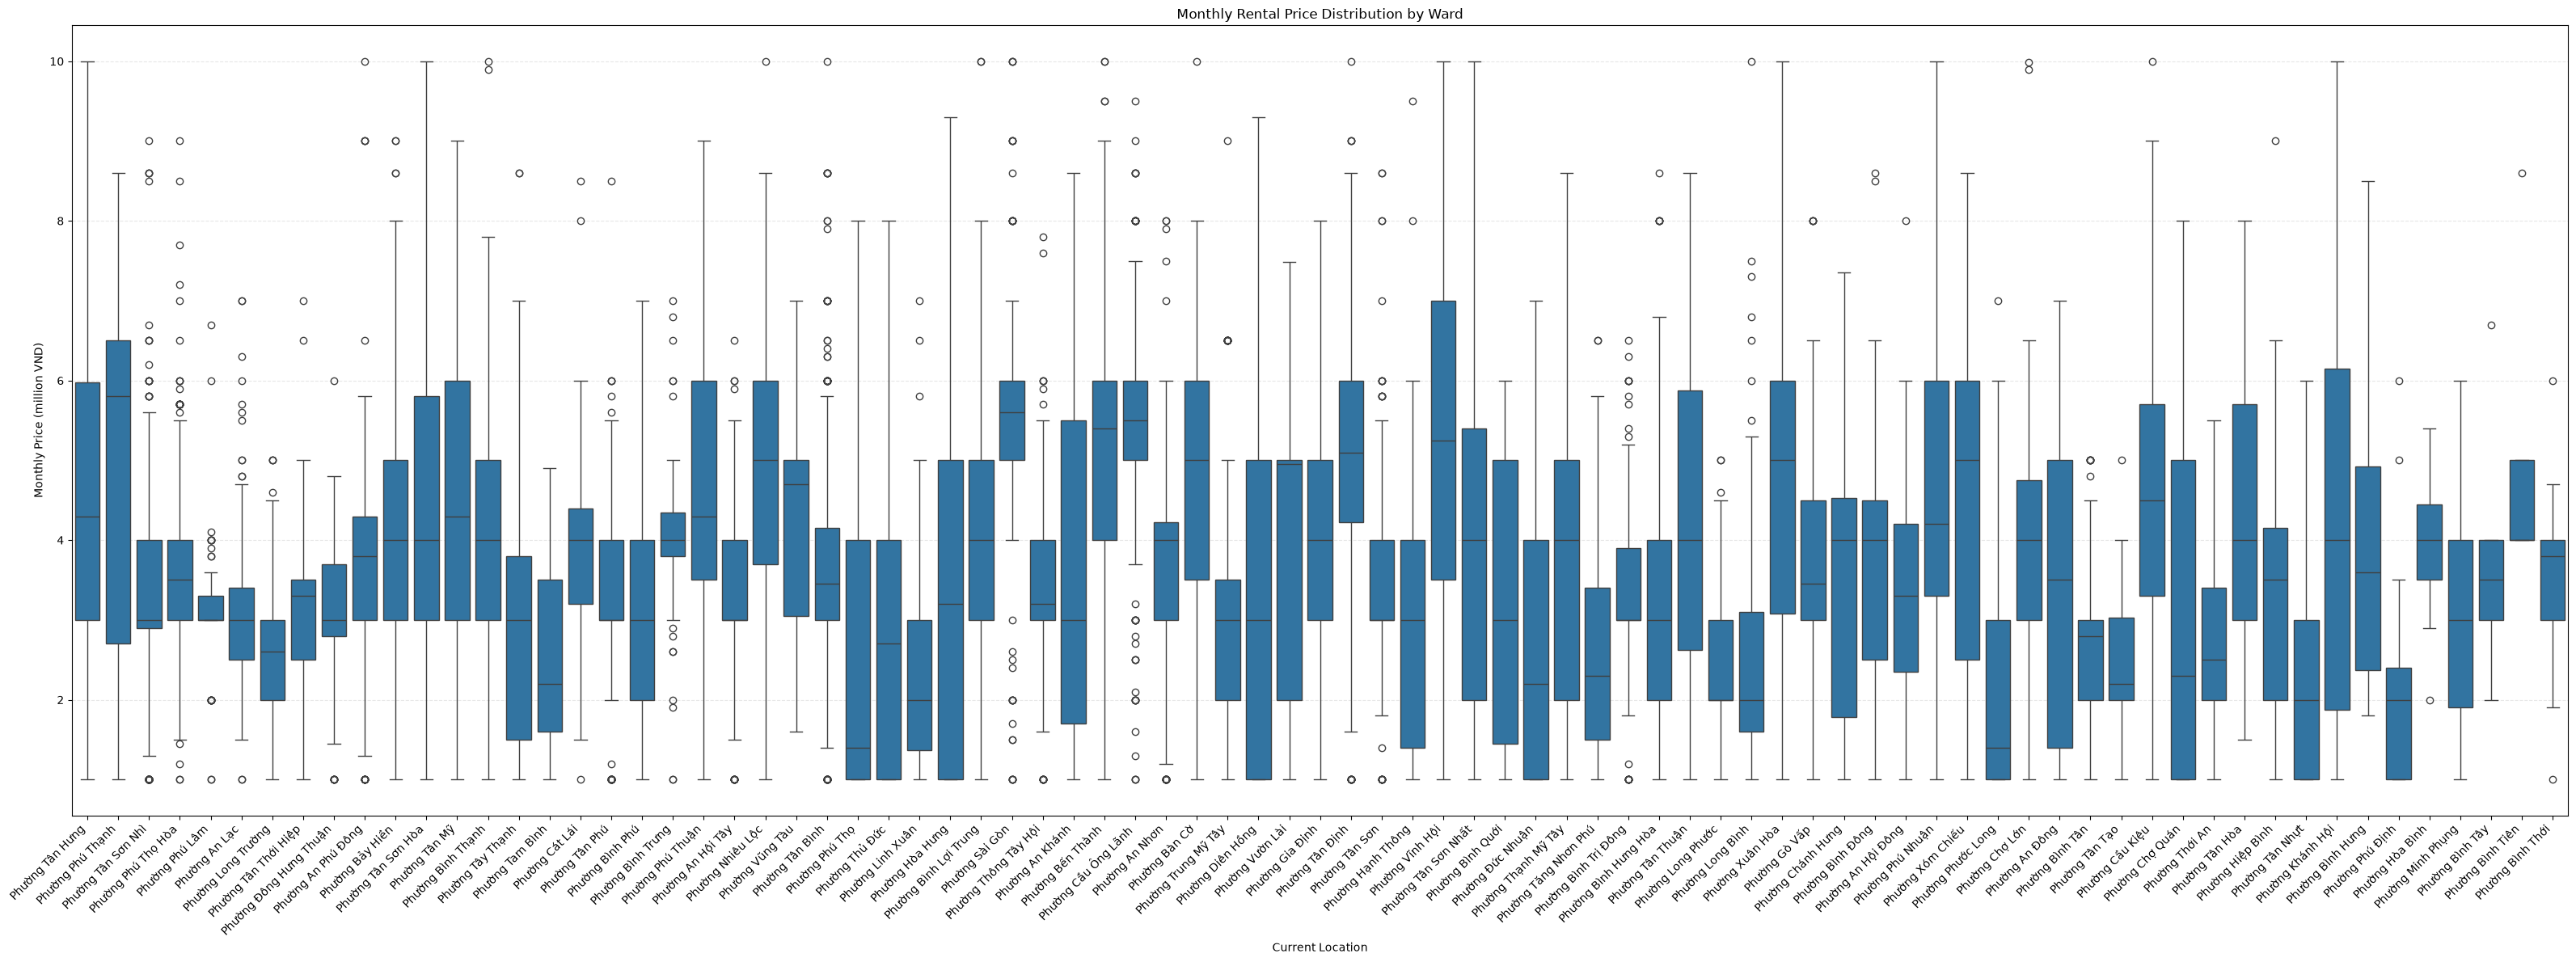

In [104]:
plt.figure(figsize=(32, 12))

sns.boxplot(
    data=plot_df_price,
    x="current_location",
    y="price_million",
)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.xlabel("Current Location")

plt.ylabel(

    "Monthly Price (million VND)"

)


plt.title(

    "Monthly Rental Price Distribution by Ward"

)


plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)

plt.tight_layout()
plt.show()

In [ ]:
# kiểm tra giá trị NaN
df_work["monthly_price"].isna().sum()

np.int64(7671)

In [ ]:
df_work[
    df_work["monthly_price"].isna()
][
    [
        "domain",
        "title",
        "post_url",
        "address"
    ]
].head(20)

,domain,title,post_url,address
113,mogi,"KTX FREE Máy Lạnh, Điện, Nước Chỉ 700k (Phú Nh...",https://mogi.vn/quan-phu-nhuan/thue-phong-tro-...,NaN
293,tromoi,Căn hộ cao cấp cạnh ngay vivo city quận 7,https://tromoi.com/can-ho/can-ho-cao-cap-canh-...,"Nằm trong khu dân cư an ninh, yên tĩnh, dân tr..."
337,chothuephongtro,️ CHO THUÊ CĂN HỘ 1 PHÒNG NGỦ FULL NỘI THẤT – ...,https://chothuephongtro.me/cho-thue-can-ho-1-p...,NaN
354,cafeland,Phòng trọ: Pass trọ quận 7,https://nhadat.cafeland.vn/phong-tro-pass-tro-...,NaN
357,cafeland,Phòng trọ: Cho Thuê Phòng Q10 rộng rãi.tolet r...,https://nhadat.cafeland.vn/phong-tro-cho-thue-...,NaN
358,cafeland,Nguyễn Quốc Mạnh Tuấn,https://nhadat.cafeland.vn/moi-gioi/nguyen-quo...,NaN
359,cafeland,Phòng trọ: Cho Thuê Phòng Q3.rộng rãi thoải má...,https://nhadat.cafeland.vn/phong-tro-cho-thue-...,NaN
366,cafeland,Phòng trọ: Phòng trọ 45m2 Hẻm 719 Huỳnh Tấn Ph...,https://nhadat.cafeland.vn/phong-tro-phong-tro...,NaN
369,cafeland,Phòng trọ: Phòng trọ Ký Túc Xá Đặng Thuỳ Trâm ...,https://nhadat.cafeland.vn/phong-tro-phong-tro...,NaN
374,cafeland,Phòng trọ: Phòng 20m² có gác sạch đẹp – Khu 5E...,https://nhadat.cafeland.vn/phong-tro-phong-20m...,NaN


In [ ]:
df_work.columns


Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'current_location'],
      dtype='str')

#### Kiểm tra điểm bất thường (outlier)
- Tính IQR
=> Giá trị nào quá xa so với phần lớn dữ liệu của chính nhóm đó?

In [ ]:
def get_outliers(df, group_col, value_col):
    """
    Lấy outlier theo từng nhóm (phường) dựa trên IQR
    """
    def iqr_outliers(group):
        q1 = group[value_col].quantile(0.25)
        q3 = group[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return group[(group[value_col] < lower) | (group[value_col] > upper)]
    
    return df.groupby(group_col, group_keys=False).apply(iqr_outliers)

In [ ]:
outliers = get_outliers(
    plot_df_price,
    group_col="current_location",
    value_col="price_million"
)

In [ ]:
outliers.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'price_million'],
      dtype='str')

In [ ]:
from IPython.display import display

display(
    outliers[
        [
            "domain",
            "title",
            "price_million",
            "area_m2",
            "address",
            "location"
        ]
    ]
    .sort_values(
        "price_million",
        ascending=False
    )
    .head(20)
)

,domain,title,price_million,area_m2,address,location
26384,mogi,Phòng trọ quận BT gần ĐẠI HỌC NGOẠI THƯƠNG,10.0,20.0,"Đường D5, Phường 11, Quận Bình Thạnh, TPHCM","Đường D5, Phường 11, Quận Bình Thạnh, TPHCM"
2122,mogi,"Cho thuê nguyên lầu 1, Bình Lợi, P.13, 5x20m, ...",10.0,100.0,"Bình Lợi, Phường 13, Quận Bình Thạnh, TPHCM","Bình Lợi, Phường 13, Quận Bình Thạnh, TPHCM"
87831,mogi,Dự án vừa mới ra mắt ngay đinh bộ lĩnh,10.0,30.0,"Đinh Bộ Lĩnh, Phường 26, Quận Bình Thạnh, TPHCM","Đinh Bộ Lĩnh, Phường 26, Quận Bình Thạnh, TPHCM"
17715,mogi,cho thuê căn hộ 2 phòng ngủ khu vực khu K300,10.0,50.0,"Bình Giã, Phường 13, Quận Tân Bình, TPHCM","Bình Giã, Phường 13, Quận Tân Bình, TPHCM"
19665,nhatot,Phòng trọ Quận Bình Thạnh - Đường Quốc lộ 13 -...,9.9,90.0,"211, Đường Quốc lộ 13, Phường 26, Quận Bình Th...","211, Đường Quốc lộ 13, Phường 26, Quận Bình Th..."
31010,chothuephongtro,Căn hộ full nội thất ở liền được ngay sân bay ...,8.6,25.0,"Tân Hải, P.13, Q. Tân Bình (ngay ETOWN) THUẬN ...","Tân Hải, P.13, Q. Tân Bình (ngay ETOWN) THUẬN ..."
28353,chothuephongtro,PHÒNG TRỌ CAO CẤP RỘNG THOÁNG NGAY ĐH CÔNG THƯ...,8.6,20.0,"Nguyễn Hữu Tiến, Phường Sơn Kỳ, Quận Tân Phú. ...","Nguyễn Hữu Tiến, Phường Sơn Kỳ, Quận Tân Phú. ..."
28759,chothuephongtro,STUDIO CÓ BAN CÔNG 40M² – FULL NỘI THẤT – GẦN ...,8.6,40.0,"Nguyễn Đức Thuận, P.13, Q. Tân Bình","Nguyễn Đức Thuận, P.13, Q. Tân Bình"
26693,chothuephongtro,KHAI TRƯƠNG DỰ ÁN STUDIO CỬA SỔ TRỜI 30M2 – FU...,8.6,30.0,"Huỳnh Văn Nghệ, P15, Quận Tân Bình","Huỳnh Văn Nghệ, P15, Quận Tân Bình"
32265,chothuephongtro,phòng trọ xịn ưu tiên sinh viên người đi làm,8.6,50.0,"Huỳnh Văn Nghệ, phường 15, quận Tân Bình, TP.HCM","Huỳnh Văn Nghệ, phường 15, quận Tân Bình, TP.HCM"


In [ ]:
outliers["price_million"].isna().sum()

np.int64(0)

#### Xóa các giá trị NaN

In [ ]:
missing_price_df = df_work[
    df_work["monthly_price"].isna()
]

len(missing_price_df)

7254

In [ ]:
missing_price_df[
    [
        "domain",
        "title",
        "area_m2",
        "address",
        "post_url"
    ]
].head(20)

,domain,title,area_m2,address,post_url
0,nhatot,Mô tả chi tiết,10.0,"Đường số 3, Phường 9, Quận Gò Vấp, Tp Hồ Chí Minh",https://www.nhatot.com/thue-phong-tro-quan-go-...
13,nhatot,Mô tả chi tiết,18.0,"14/21 Hoàng Dư Khương, Hẻm 14 Hoàng Dư Khương,...",https://www.nhatot.com/thue-phong-tro-quan-10-...
106,mogi,"KTX 0 đồng, Phòng trọ 0 đồng - 289 Tô Hiến Thành",21.0,NaN,https://mogi.vn/quan-10/thue-phong-tro-khu-nha...
192,tromoi,Căn hộ cao cấp cạnh ngay vivo city quận 7,NaN,"Nằm trong khu dân cư an ninh, yên tĩnh, dân tr...",https://tromoi.com/can-ho/can-ho-cao-cap-canh-...
236,tromoi,"KÝ TÚC XÁ SINH VIÊN GẦN HUIT, HUFI, NTTU, HITC...",NaN,"55A Nguyễn Đổ Cung, Phường Tây Thạnh, Quận Tân...",https://tromoi.com/ky-tuc-xa/ki-tuc-xa-thien-dang
306,nhatrovn,402,20.0,"13/xx/x Trần Văn Hoàng, Phường 10, Quận Tân Bì...",https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...
412,cafeland,Phòng trọ: cho thuê phòng có gác với máy lạnh,NaN,NaN,https://nhadat.cafeland.vn/phong-tro-cho-thue-...
413,cafeland,Phòng trọ: Cho thuê phòng trọ ghép 1tr450k trọ...,NaN,NaN,https://nhadat.cafeland.vn/phong-tro-cho-thue-...
414,cafeland,Phòng trọ: Cho Thuê Phòng Q10 rộng rãi.tolet r...,NaN,NaN,https://nhadat.cafeland.vn/phong-tro-cho-thue-...
415,cafeland,Cát Bình,NaN,NaN,https://nhadat.cafeland.vn/moi-gioi/cat-binh-2...


In [ ]:
missing_price_count = (
    df_work["monthly_price"]
    .isna()
    .sum()
)

missing_rate = (
    df_work["monthly_price"]
    .isna()
    .mean()
)

In [ ]:
df_work = df_work.dropna(
    subset=["monthly_price"]
).copy()

In [ ]:
print("Before:", len(df_work))


Before: 89330


In [ ]:
df_work.head(20)

,domain,roombeacon_id,website_id,title,post_url,monthly_price,area_m2,address,location,address_inherited,latest_seen_at,first_seen_at,last_seen_at,active_days,address_clean,current_location
0,mogi,801385,22083383,Cho thuê phòng trọ mới xây full bancol gần ĐH ...,https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,3000000.0,30.0,"Dương Quảng Hàm, Phường 5, Quận Gò Vấp, TPHCM","Dương Quảng Hàm, Phường 5, Quận Gò Vấp, TPHCM",False,2026-08-31 16:10:12,2026-08-28 06:10:11,2026-08-31 16:10:12,3,"Dương Quảng Hàm, Phường 5, Quận Gò Vấp, TPHCM",[Phường An Nhơn]
1,mogi,801384,22018523,Cho thuê phòng trọ full nội thất ở phường 17 -...,https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,4000000.0,30.0,"Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM","Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM",False,2026-08-31 16:10:10,2026-08-28 06:10:10,2026-08-31 16:10:10,3,"Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM",[Phường Gò Vấp]
2,mogi,801383,22091928,Cho thuê phòng trọ mới xây full bancol gần ĐH ...,https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,4000000.0,30.0,"Dương Quảng Hàm, Phường 6, Quận Gò Vấp, TPHCM","Dương Quảng Hàm, Phường 6, Quận Gò Vấp, TPHCM",False,2026-08-31 16:10:08,2026-08-28 06:10:10,2026-08-31 16:10:08,3,"Dương Quảng Hàm, Phường 6, Quận Gò Vấp, TPHCM",[Phường An Nhơn]
3,mogi,801382,22170853,Cho thuê phòng trọ mới xây ngay Chợ Phạm Văn H...,https://mogi.vn/quan-phu-nhuan/thue-phong-tro-...,3000000.0,30.0,"Huỳnh Văn Bánh, Phường 10, Quận Phú Nhuận, TPHCM","Huỳnh Văn Bánh, Phường 10, Quận Phú Nhuận, TPHCM",False,2026-08-31 16:10:06,2026-08-28 06:10:10,2026-08-31 16:10:06,3,"Huỳnh Văn Bánh, Phường 10, Quận Phú Nhuận, TPHCM",[Phường Phú Nhuận]
4,mogi,801381,22151570,Cho thuê phòng trọ giá sinh viên ngay Đại học ...,https://mogi.vn/quan-binh-thanh/thue-phong-tro...,3000000.0,30.0,"Điện Biên Phủ, Phường 17, Quận Bình Thạnh, TPHCM","Điện Biên Phủ, Phường 17, Quận Bình Thạnh, TPHCM",False,2026-08-31 16:10:04,2026-08-28 06:10:10,2026-08-31 16:10:04,3,"Điện Biên Phủ, Phường 17, Quận Bình Thạnh, TPHCM",[Phường Gia Định]
5,mogi,801380,21657706,"Cho thuê căn hộ dịch vụ mới xây ở Nguyễn Oanh,...",https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,6000000.0,25.0,"Nguyễn Oanh, Phường 17, Quận Gò Vấp, TPHCM","Nguyễn Oanh, Phường 17, Quận Gò Vấp, TPHCM",False,2026-08-31 16:10:02,2026-08-28 06:10:10,2026-08-31 16:10:02,3,"Nguyễn Oanh, Phường 17, Quận Gò Vấp, TPHCM",[Phường Gò Vấp]
6,mogi,801379,22176032,Cho thuê phòng trọ mới xây ngay Chợ Phạm Văn H...,https://mogi.vn/quan-phu-nhuan/thue-phong-tro-...,4000000.0,30.0,"Trần Hữu Trang, Phường 10, Quận Phú Nhuận, TPHCM","Trần Hữu Trang, Phường 10, Quận Phú Nhuận, TPHCM",False,2026-08-31 16:10:00,2026-08-28 06:10:10,2026-08-31 16:10:00,3,"Trần Hữu Trang, Phường 10, Quận Phú Nhuận, TPHCM",[Phường Phú Nhuận]
7,mogi,801378,22151575,Cho thuê phòng trọ giá sinh viên ngay Bến Xe M...,https://mogi.vn/quan-binh-thanh/thue-phong-tro...,3000000.0,30.0,"Đinh Bộ Lĩnh, Phường 24, Quận Bình Thạnh, TPHCM","Đinh Bộ Lĩnh, Phường 24, Quận Bình Thạnh, TPHCM",False,2026-08-31 16:09:58,2026-08-28 06:10:10,2026-08-31 16:09:58,3,"Đinh Bộ Lĩnh, Phường 24, Quận Bình Thạnh, TPHCM",[]
8,mogi,801377,22091920,Cho thuê phòng trọ mới xây ngay chợ căn cứ Lê ...,https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,4000000.0,30.0,"Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM","Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM",False,2026-08-31 16:09:56,2026-08-28 06:10:10,2026-08-31 16:09:56,3,"Lê Thị Hồng, Phường 17, Quận Gò Vấp, TPHCM",[Phường Gò Vấp]
9,mogi,801376,21947002,Cho thuê trọ giá rẻ full nội thất ở Gò Vấp,https://mogi.vn/quan-go-vap/thue-phong-tro-khu...,3000000.0,25.0,"Trần Bá Giao, Phường 5, Quận Gò Vấp, TPHCM","Trần Bá Giao, Phường 5, Quận Gò Vấp, TPHCM",False,2026-08-31 16:09:54,2026-08-28 06:10:10,2026-08-31 16:09:54,3,"Trần Bá Giao, Phường 5, Quận Gò Vấp, TPHCM",[Phường An Nhơn]
